# NB01 — Setup

Role of the notebook: to initialise one city run, resolve all city-specific inputs from the YAML configuration, and verify that the raw datasets needed downstream are present and coherent before any hazard, exposure, vulnerability, or adaptation modelling begins.

Specifically, this notebook:
- selects the city copy and loads the corresponding config file;
- syncs the raw city inputs from Google Drive;
- optionally downloads historical UrbClim daily-mean 2 m air temperature (`T2M`) files from the PROVIDE/VITO API when this is enabled in the config;
- inspects the Functional Urban Area (FUA), Local Climate Zones (LCZ), Green View Index (GVI), historical UrbClim `T2M`, and cooling-efficiency coefficient tables;
- saves an FUA-masked LCZ raster for reuse in later notebooks.

NB01 is therefore a diagnostic and organisational notebook. It makes the workflow reproducible, confirms that the configuration points to the expected inputs, and provides a first audit of the spatial and climate layers that structure the rest of the framework.


In [1]:
import sys
import importlib
import importlib.metadata as im

import numpy as np, pandas as pd
import climada as cl
import xarray as xr, rasterio, geopandas as gpd

print("Python:", sys.version.split()[0])
print("Kernel exe:", sys.executable)
print("climada module path:", getattr(cl, "__file__", "<none>"))

try:
    print("CLIMADA:", cl.__version__)
except AttributeError:
    try:
        print("CLIMADA:", im.version("climada"))
    except im.PackageNotFoundError:
        print("CLIMADA: <not found in package metadata>")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("rasterio:", rasterio.__version__)
print("geopandas:", gpd.__version__)

Python: 3.10.19
Kernel exe: /opt/anaconda3/envs/urbanheat/bin/python
climada module path: /opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/climada/__init__.py
CLIMADA: 6.1.0
NumPy: 1.26.4
Pandas: 2.1.4
xarray: 2025.6.1
rasterio: 1.4.3
geopandas: 1.1.1


In [2]:
# Select the city to run
import os
os.environ["CITY"] = "Athens"   # pick the city here
os.environ["WP_ISO3"] = "GRC"
os.environ["WP_COUNTRY"] = "Greece"

In [3]:
# Load the city YAML config, resolve the main paths, and prepare output locations.
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# `CITY` is the authoritative selector; the fallback below is only a notebook-local default.
SLUG = globals().get("SLUG", os.environ.get("CITY", "Athens")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")


→ City: athens  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim


In [4]:
# Sync input data from Google Drive (downloads only if not already present)
from pathlib import Path
import json, gdown
from datetime import datetime

CFG_PATH = C["CFG"]          # Path to configs/<slug>.yml
cfg      = C["cfg"]          # dict loaded from YAML
base_dir = Path(C["BASE"]).resolve()

manifest_path = (ROOT / cfg["drive_manifest"]).resolve()
M = json.loads(Path(manifest_path).read_text())

def _append_log(path: Path, line: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as fh:
        fh.write(line + "\n")

def _sidecar(p: Path) -> Path:
    return p.with_suffix(p.suffix + ".synced")

def _need(dest: Path, force: bool) -> bool:
    sc = _sidecar(dest)
    return force or (not dest.exists()) or (not sc.exists())

def _note_ok(dest: Path, id_: str):
    sc = _sidecar(dest)
    sc.write_text(json.dumps({"id": id_, "size": dest.stat().st_size if dest.exists() else None,
                              "when": datetime.now().isoformat()}))

def sync_from_gdrive(M, base_dir: Path, use_cookies=True, force=False, only=None):
    base_dir.mkdir(parents=True, exist_ok=True)
    failures = []
    def _selected(rel): return True if not only else any(rel.startswith(pfx) for pfx in only)

    for e in M["entries"]:
        if not _selected(e["dest"]): 
            continue
        e_type, e_id = e.get("type", "file"), e["id"]
        dest = (base_dir / e["dest"]).resolve()
        dest.parent.mkdir(parents=True, exist_ok=True)
        try:
            if e_type == "folder":
                marker = dest / ".synced.ok"
                needs = force or (not dest.exists()) or (not any(dest.iterdir())) or (not marker.exists())
                if needs:
                    print(f"↻ Folder: {e_id} → {dest}")
                    gdown.download_folder(id=e_id, output=str(dest), quiet=False,
                                          use_cookies=use_cookies, remaining_ok=True)
                    marker.write_text(json.dumps({"id": e_id, "when": datetime.now().isoformat()}))
                else:
                    print(f"✓ Folder up-to-date: {dest}")
            else:
                if _need(dest, force):
                    print(f"↻ File:   {e_id} → {e['dest']}")
                    url = f"https://drive.google.com/uc?id={e_id}"
                    out = gdown.download(url=url, output=str(dest), quiet=False, use_cookies=use_cookies)
                    if out is None or not dest.exists():
                        raise RuntimeError("gdown returned None or file missing.")
                    _note_ok(dest, e_id)
                else:
                    print(f"✓ File up-to-date: {e['dest']}")
        except Exception as ex:
            errlog = (dest if e_type == "file" else (dest/".folder")).with_suffix(".sync_errors.log")
            _append_log(errlog, f"[{datetime.now().isoformat()}] {e_type.upper()} {e_id} → {dest} FAILED: {ex}")
            print(f"✗ FAIL {e_type} {dest} — {ex}")
            failures.append({"type": e_type, "id": e_id, "dest": str(dest), "error": str(ex)})

    if failures:
        print("\n=== SUMMARY: failures that need attention ===")
        for f in failures:
            print(f"- {f['type']} → {f['dest']} :: {f['error']}\n"
                  f"  Action: check Drive item and update ID in {manifest_path}")
    else:
        print("\nAll entries synced successfully.")

print(f"→ Syncing Drive for {cfg['city_name']} (slug={SLUG}) from {manifest_path}")
sync_from_gdrive(M, base_dir, use_cookies=True, force=False)

→ Syncing Drive for Athens (slug=athens) from /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data_manifests/athens_gdrive.json
✓ File up-to-date: fua/athens_fua_ghs_4326.dbf
✓ File up-to-date: fua/athens_fua_ghs_4326.geojson
✓ File up-to-date: fua/athens_fua_ghs_4326.prj
✓ File up-to-date: fua/athens_fua_ghs_4326.shp
✓ File up-to-date: fua/athens_fua_ghs_4326.shx
✓ File up-to-date: gvi/gvi_356_cities.csv
✓ File up-to-date: LCZ/00_global_map_of_LCZs.png
✓ File up-to-date: LCZ/lcz_filter_v3.tif
✓ File up-to-date: LCZ/lcz_v3.tif
✓ File up-to-date: vulnerability/GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0.tif
✓ File up-to-date: vulnerability/ESTAT_OBS-VALUE-T_2021_V2.tiff
✓ File up-to-date: vulnerability/ESTAT_OBS-VALUE-OTH_2021_V2.tiff
✓ File up-to-date: vulnerability/ESTAT_OBS-VALUE-EMP_2021_V2.tiff
✓ File up-to-date: vulnerability/ESTAT_OBS-VALUE-Y_1564_2021_V2.tiff
✓ File up-to-date: CoolingEff/coefs_GVI_lst.csv
✓ File up-to-date: T2MmeanDeltas/climate_change_provide_m

In [5]:
# Download UrbClim daily-mean T2M NetCDFs (2008-2017) from PROVIDE/VITO API
import requests, re
from pathlib import Path

clim_cfg = cfg.get("climate", {})
api_cfg  = clim_cfg.get("urbclim_api", {})

def ensure_urbclim_t2m_from_api(api_cfg, base_dir: Path):
    if not api_cfg.get("enabled", False):
        print("UrbClim API download disabled in config.")
        return

    url       = api_cfg.get("t2m_url")
    local_rel = api_cfg.get("local_dir", "UrbClim/UrbClimT2Mmean")
    years     = api_cfg.get("years", list(range(2008, 2018)))

    if not url:
        print("No 't2m_url' configured in climate.urbclim_api → skipping.")
        return

    local_dir = (base_dir / local_rel).resolve()
    local_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n→ Ensuring UrbClim T2M (daily mean) from API:")
    print(f"   URL:      {url}")
    print(f"   Local dir:{local_dir}")
    print(f"   Years:    {years}")

    try:
        r = requests.get(url)
        r.raise_for_status()
    except Exception as ex:
        print(f" Failed to fetch directory listing from API: {ex}")
        return

    # Find all .nc links in the HTML directory listing
    links = re.findall(r'href="([^"]+\.nc)"', r.text)
    available = set(links)

    for year in years:
        fname = f"T2M_year_daily_mean_{year}.nc"
        dest  = local_dir / fname

        if dest.exists():
            print(f"✓ {fname} already present locally.")
            continue

        if fname not in available:
            print(f"⚠ {fname} not found in API listing at {url}")
            continue

        file_url = url.rstrip("/") + "/" + fname
        print(f" Downloading {file_url} → {dest}")
        try:
            with requests.get(file_url, stream=True) as resp:
                resp.raise_for_status()
                with open(dest, "wb") as f:
                    for chunk in resp.iter_content(chunk_size=2**20):
                        if chunk:
                            f.write(chunk)
        except Exception as ex:
            print(f" Failed to download {fname}: {ex}")

ensure_urbclim_t2m_from_api(api_cfg, base_dir)


→ Ensuring UrbClim T2M (daily mean) from API:
   URL:      https://provide.marvin.vito.be/ftp/compressed_daily/Athens/
   Local dir:/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/UrbClim/UrbClimT2Mmean
   Years:    [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
✓ T2M_year_daily_mean_2008.nc already present locally.
✓ T2M_year_daily_mean_2009.nc already present locally.
✓ T2M_year_daily_mean_2010.nc already present locally.
✓ T2M_year_daily_mean_2011.nc already present locally.
✓ T2M_year_daily_mean_2012.nc already present locally.
✓ T2M_year_daily_mean_2013.nc already present locally.
✓ T2M_year_daily_mean_2014.nc already present locally.
✓ T2M_year_daily_mean_2015.nc already present locally.
✓ T2M_year_daily_mean_2016.nc already present locally.
✓ T2M_year_daily_mean_2017.nc already present locally.


## Packages and Path Resolution

From this point on, the notebook shifts from setup to input inspection. We import the geospatial and NetCDF stack used throughout the framework and resolve data locations through the config-driven helper `P()`, so that the same notebook logic can run for different cities without hard-coded local paths.


In [6]:
import os, sys, glob, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Geospatial I/O and analysis
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
import geopandas as gpd
from rasterio.mask import mask
import rasterio as rio

# NetCDF handling for UrbClim climate grids
import xarray as xr

plt.rcParams["figure.dpi"] = 130

# Define paths to each input dataset directory via the config-driven helper
p_LCZ     = P("LCZ")
p_UrbClim = P("UrbClim/UrbClimT2Mmean")   
gvi_csv = P(cfg["files"]["gvi_csv"])
p_GVI   = gvi_csv.parent 
p_CoolEff = P("CoolingEff")              
p_FUA     = P("fua")

In [7]:
# Quick inventory of available input files
coolingeff_csvs = sorted(p_CoolEff.glob("*.csv"))
print("CoolingEff CSVs:", [f.name for f in coolingeff_csvs] or "none (folder is empty)")

nc_files = sorted(p_UrbClim.glob("T2M_year_daily_mean*.nc"))
print(f"UrbClim .nc files found: {len(nc_files)}")
for f in nc_files[:6]:
    print(" •", f.name)

CoolingEff CSVs: ['coefs_GVI_lst.csv']
UrbClim .nc files found: 10
 • T2M_year_daily_mean_2008.nc
 • T2M_year_daily_mean_2009.nc
 • T2M_year_daily_mean_2010.nc
 • T2M_year_daily_mean_2011.nc
 • T2M_year_daily_mean_2012.nc
 • T2M_year_daily_mean_2013.nc


## Functional Urban Area Boundary

The Functional Urban Area defines the main study domain used throughout the framework. In NB01 it is used to inspect and clip inputs; downstream it helps anchor a consistent spatial analysis domain across datasets with different native formats, extents, and resolutions. Comes from an R script I've written.


In [12]:
from pathlib import Path

p_FUA = P("fua")

# Load FUA boundary (GHS-FUA database, EPSG:4326)
candidates = list(p_FUA.glob(f"*{SLUG}*_ghs_4326.*"))
prio = {".geojson": 0, ".gpkg": 1, ".shp": 2}
candidates = sorted(candidates, key=lambda p: prio.get(p.suffix.lower(), 99))
assert candidates, f"No FUA file found for {SLUG} in {p_FUA}"
fua_path = candidates[0]

fua = gpd.read_file(fua_path)
print("FUA CRS:", fua.crs)
display(fua.head())

FUA CRS: EPSG:4326


,name,iso,efua_id,geometry
0,Athens,GRC,959.0,"POLYGON ((23.8718 38.31322, 23.86997 38.30435,..."


## Input Audit

The rest of the notebook is a structured audit of the core inputs. The aim is not to transform them yet, but to verify that they cover the right city, expose the expected schema, and behave as anticipated before NB02 builds the harmonised analysis layers.


### Local Climate Zones (LCZ)

The LCZ raster describes the spatial mosaic of urban and natural surface types within the study area. The standard LCZ taxonomy contains 17 classes: 10 built classes and 7 natural classes. This layer is useful both as an early descriptive summary of urban form and later in the framework, where LCZ-specific information is used when modelling vegetation cooling.


In [13]:
# List files in LCZ directory — lcz_filter_v3.tif is the filtered classification used downstream
list(p_LCZ.glob("*"))

[PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/00_global_map_of_LCZs.png.synced'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/00_global_map_of_LCZs.png'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/lcz_filter_v3.tif'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/lcz_v3.tif.synced'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/lcz_v3.tif'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/lcz_filter_v3.tif.synced')]

In [14]:
lcz_path = P("LCZ/lcz_filter_v3.tif")

with rasterio.open(lcz_path) as src:
    # Reproject FUA to match the raster CRS for correct spatial masking
    fua_aligned = fua.to_crs(src.crs)
    geoms = [g.__geo_interface__ for g in fua_aligned.geometry if g is not None]

    # Mask and crop LCZ raster to the FUA bounding box
    out, out_transform = mask(src, geoms, crop=True, filled=True)
    # Pixels outside the FUA polygon (but inside the bounding box) are set to nodata
    lcz_fua = out[0]                       # single-band raster
    lcz_meta = src.meta.copy()
    lcz_meta.update({"transform": out_transform,
                     "height": lcz_fua.shape[0],
                     "width":  lcz_fua.shape[1]})
    nodata_val = src.nodata
    # Valid pixels have LCZ codes 1-17; pixels outside the FUA are nodata (0.0)
print("LCZ masked shape:", lcz_fua.shape, "| nodata:", nodata_val)

LCZ masked shape: (641, 757) | nodata: 0.0


The masked raster below is cropped to the smallest rectangle containing the FUA. Cells outside the polygon but inside that crop are written as nodata, so valid LCZ counts must be computed explicitly rather than inferred from the array size alone.


### Quick LCZ Preview

This first map is a visual sanity check that the masking worked as intended and that the LCZ footprint looks plausible before we compute formal summaries.


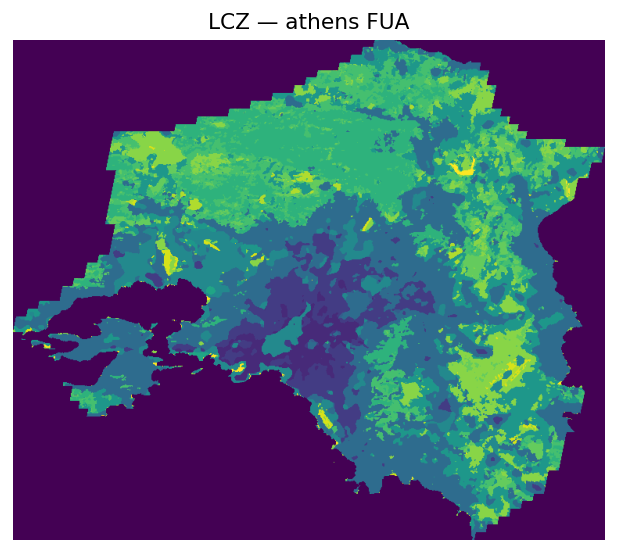

In [15]:
plt.figure(figsize=(6,5))
plt.imshow(lcz_fua, origin="upper")
plt.title(f"LCZ — {CITY} FUA")
plt.axis("off")
plt.show()

In [16]:
# Basic pixel-count sanity checks on the masked LCZ raster.
total_pixels = lcz_fua.size
nodata_pixels = (lcz_fua == nodata_val).sum()
valid_pixels = (lcz_fua > 0).sum()

print("Total pixels in crop:", total_pixels)
print("Nodata pixels:", nodata_pixels)
print("Valid LCZ pixels (inside FUA):", valid_pixels)

n_lcz_pixels_fua = int(((np.isfinite(lcz_fua)) & (lcz_fua > 0)).sum())
print("LCZ pixels in {CITY} FUA:", n_lcz_pixels_fua)


Total pixels in crop: 485237
Nodata pixels: 226471
Valid LCZ pixels (inside FUA): 258766
LCZ pixels in {CITY} FUA: 258766


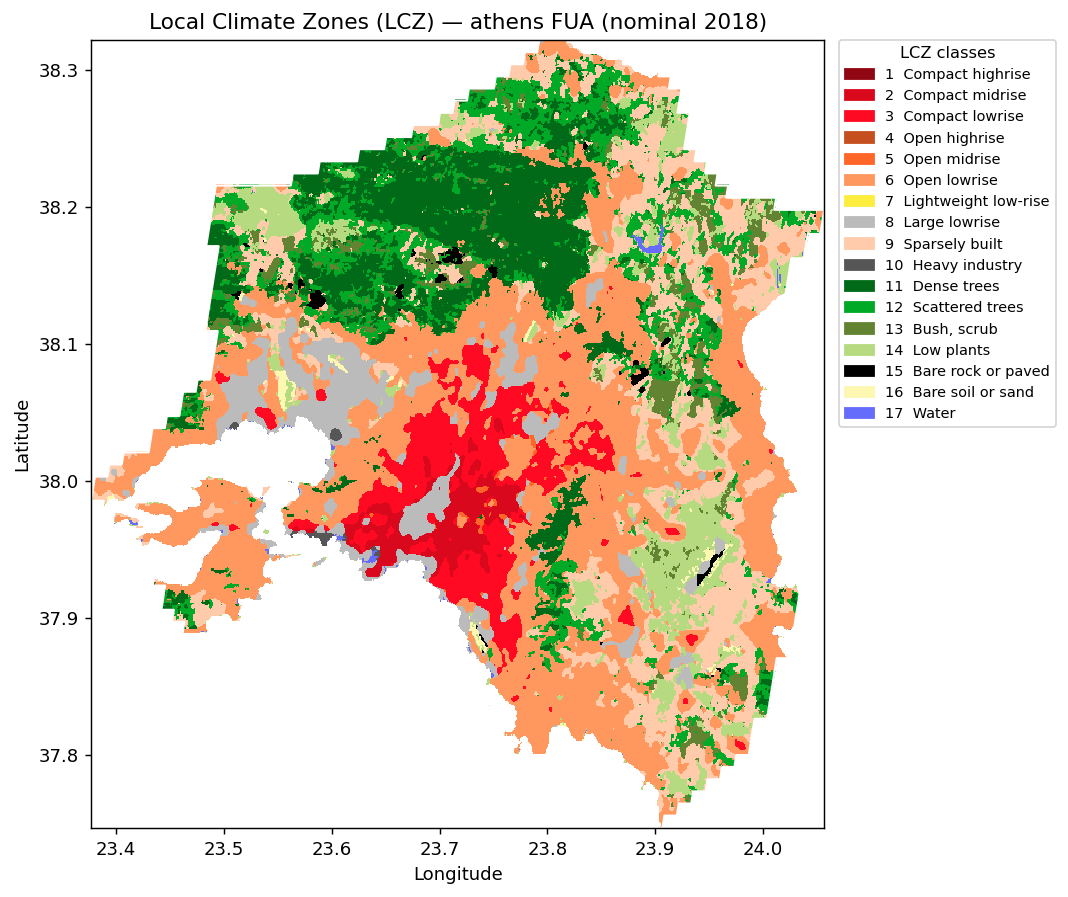

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.transform import array_bounds

# Cast to integer codes (LCZ classes 1-17, nodata is 0)
lcz_int = lcz_fua.astype(np.int16)

# Official LCZ colour scheme and labels 
LCZ_COLORS = {
    1:"#910613",  2:"#D9081C",  3:"#FF0A22",  4:"#C54F1E",  5:"#FF6628",
    6:"#FF985E",  7:"#FDED3F",  8:"#BBBBBB",  9:"#FFCBAB", 10:"#565656",
   11:"#006A18", 12:"#00A926", 13:"#628432", 14:"#B5DA7F", 15:"#000000",
   16:"#FCF7B1", 17:"#656BFA",
}
LCZ_LABELS = {
    1:"Compact highrise", 2:"Compact midrise", 3:"Compact lowrise",
    4:"Open highrise", 5:"Open midrise", 6:"Open lowrise",
    7:"Lightweight low-rise", 8:"Large lowrise", 9:"Sparsely built",
    10:"Heavy industry",
    11:"Dense trees", 12:"Scattered trees", 13:"Bush, scrub",
    14:"Low plants", 15:"Bare rock or paved", 16:"Bare soil or sand", 17:"Water",
}

# Build colormap with index 0 as transparent nodata
colors = ["#00000000"] + [LCZ_COLORS[i] for i in range(1, 18)]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 18.5, 1), cmap.N)

# Geographic extent from the cropped transform
H, W = lcz_int.shape
bottom, top = array_bounds(H, W, out_transform)[1], array_bounds(H, W, out_transform)[3]
left, right = array_bounds(H, W, out_transform)[0], array_bounds(H, W, out_transform)[2]
extent = (left, right, bottom, top)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    lcz_int,
    cmap=cmap,
    norm=norm,
    extent=extent,
    origin="upper",
    interpolation="nearest"
)

# Overlay FUA boundary
fua_aligned.boundary.plot(ax=ax, color="white", linewidth=1.2)

ax.set_title(f"Local Climate Zones (LCZ) — {CITY} FUA (nominal 2018)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

patches = [
    mpatches.Patch(color=LCZ_COLORS[i], label=f"{i}  {LCZ_LABELS[i]}")
    for i in range(1, 18)
]
ax.legend(
    handles=patches,
    title="LCZ classes",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
plt.show()

### LCZ Composition Within the FUA

We next count valid LCZ pixels by class and convert those counts into percentage shares within the FUA. This provides a compact description of the study-domain composition before later notebooks move to harmonised grids and policy modelling.


In [18]:
# Keep valid LCZ pixels only: classes 1-17 inside the FUA.
valid = np.isfinite(lcz_fua) & (lcz_fua > 0)
vals = lcz_fua[valid].astype(int)

uniq, cnt = np.unique(vals, return_counts=True)

# LCZ labels used to turn the class counts into a readable summary table.
lcz_names = {
    1:"Compact highrise",  2:"Compact midrise",  3:"Compact lowrise",
    4:"Open highrise",     5:"Open midrise",     6:"Open lowrise",
    7:"Lightweight low-rise", 8:"Large lowrise", 9:"Sparsely built",
    10:"Heavy industry",
    11:"Dense trees", 12:"Scattered trees", 13:"Bush, scrub",
    14:"Low plants",  15:"Bare rock/paved", 16:"Bare soil/sand", 17:"Water"
}

df_lcz = (pd.DataFrame({"LCZ": uniq, "pixels": cnt})
            .assign(name=lambda d: d["LCZ"].map(lcz_names),
                    share_pct=lambda d: 100 * d["pixels"] / d["pixels"].sum())
            .sort_values("LCZ")
            .reset_index(drop=True))

display(df_lcz)


,LCZ,pixels,name,share_pct
0,2,6224,Compact midrise,2.405262
1,3,18138,Compact lowrise,7.009422
2,5,485,Open midrise,0.187428
3,6,83796,Open lowrise,32.382925
4,8,16981,Large lowrise,6.562300
5,9,40211,Sparsely built,15.539522
6,10,391,Heavy industry,0.151102
7,11,34253,Dense trees,13.237056
8,12,27005,Scattered trees,10.436070
9,13,9588,"Bush, scrub",3.705278


`share_pct` is the percentage contribution of each LCZ class among valid LCZ pixels inside the FUA. It is therefore a composition within the analysed urban domain, not within the cropped raster rectangle.


### Composition of Built LCZ Classes Only

Because the LCZ taxonomy mixes built and natural classes, it is also useful to recompute shares within the built subset alone (`LCZ 1-10`). This isolates the relative mix of urban form types without natural classes dominating the denominator.


In [19]:
# Recompute shares within the built subset only (LCZ 1-10).
built_mask = df_lcz["LCZ"].between(1, 10)
built_total = df_lcz.loc[built_mask, "pixels"].sum()

df_lcz_built = (df_lcz.loc[built_mask, ["LCZ","name","pixels"]]
                    .assign(share_pct_within_built=lambda d: 100 * d["pixels"] / built_total)
                    .reset_index(drop=True))

print("Shares over BUILT classes only (1–10):")
display(df_lcz_built)


Shares over BUILT classes only (1–10):


,LCZ,name,pixels,share_pct_within_built
0,2,Compact midrise,6224,3.744300
1,3,Compact lowrise,18138,10.911650
2,5,Open midrise,485,0.291771
3,6,Open lowrise,83796,50.410886
4,8,Large lowrise,16981,10.215610
5,9,Sparsely built,40211,24.190560
6,10,Heavy industry,391,0.235222


`share_pct_within_built` answers a different question from `share_pct`: among built LCZ pixels only, how are the built classes distributed? It should not be interpreted as the share of the whole FUA occupied by each built class.


### Built Versus Natural Balance

Finally, we collapse the LCZ composition into a simple built-versus-natural split to provide one more high-level diagnostic of the study domain.


In [20]:
total_valid = df_lcz["pixels"].sum()
built_total = df_lcz.loc[df_lcz["LCZ"].between(1,10), "pixels"].sum()
natural_total = total_valid - built_total

print("Built share of FUA (%):", 100 * built_total / total_valid)
print("Natural share of FUA (%):", 100 * natural_total / total_valid)

Built share of FUA (%): 64.23796016478208
Natural share of FUA (%): 35.76203983521792


### Green View Index (GVI)

The GVI file is a point-based greenness dataset. Here we filter it to the city under study and check that the columns required downstream are present. NB01 only verifies structure and coverage; the policy use of GVI comes later in the vegetation notebook.


In [21]:
gvi_csv = P(cfg["files"]["gvi_csv"])
print("GVI file:", gvi_csv)

gvi = pd.read_csv(gvi_csv)

# Keep only the rows belonging to the city selected in the config.
gvi = gvi[gvi["city"].str.strip().str.lower() == cfg["city_name"].strip().lower()].copy()

display(gvi.head())
gvi.info()

# Verify the minimum schema expected by the downstream vegetation workflow.
need_cols = {"x", "y", "lcz_filter_v3", "gvi"}
missing = need_cols - set(gvi.columns)
assert not missing, f"GVI CSV missing columns: {missing}"
assert len(gvi) > 0, f"No GVI rows found for city {cfg['city_name']}"


GVI file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/gvi/gvi_356_cities.csv


,Unnamed: 0,city,x,y,lcz_filter_v3,gvi
47946,47947,Athens,23.622530,37.977595,6.0,12.831107
47947,47948,Athens,23.628570,37.971665,3.0,8.218305
47948,47949,Athens,23.629644,37.978589,3.0,8.123962
47949,47950,Athens,23.629724,37.973357,3.0,9.957899
47950,47951,Athens,23.629809,37.988953,3.0,13.230841


<class 'pandas.core.frame.DataFrame'>
Index: 2904 entries, 47946 to 50849
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2904 non-null   int64  
 1   city           2904 non-null   object 
 2   x              2904 non-null   float64
 3   y              2904 non-null   float64
 4   lcz_filter_v3  2897 non-null   float64
 5   gvi            2904 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 158.8+ KB


### Historical UrbClim Daily-Mean `T2M`

Historical UrbClim `T2M` is the climate input inspected in this notebook because it becomes the core heat field used later to build hazard layers. Here we check file availability, inspect sample NetCDF structure, and summarise the 2008-2017 monthly climatological cycle.


The objective of this section is diagnostic rather than analytical: we make sure the expected NetCDF files are present, that their time dimension is sensible, and that the baseline `T2M` field looks plausible both spatially and seasonally before NB02 constructs harmonised hazard inputs.


In [22]:
# inspecting a few UrbClim NetCDF files (metadata only)

print("UrbClim folder:", p_UrbClim)

nc_files = sorted(p_UrbClim.rglob("*.nc"))
print(f"Found {len(nc_files)} NetCDF file(s).")

# picking a small sample to inspect 
N = 6
sample = nc_files[:N]
for i, f in enumerate(sample, 1):
    print("\n" + "="*100)
    print(f"[{i}/{len(sample)}] FILE: {f.name}")
    try:
        # open, not loading arrays into memory
        ds = xr.open_dataset(f, decode_times=True)
    except Exception as e:
        print("Could not open dataset:", e)
        continue

    # Basic structure
    print("  ─ dims:", dict(ds.sizes))
    print("  ─ coords:", list(ds.coords))
    print("  ─ data_vars:", list(ds.data_vars))

    # show time coverage if present
    if "time" in ds.coords:
        try:
            t0 = ds["time"].isel(time=0).values
            t1 = ds["time"].isel(time=-1).values
            print("  ─ time range:", t0, "→", t1, f"({ds.sizes.get('time', 'no time')} steps)")
        except Exception as e:
            print("  ─ time coordinate present but could not summarize:", e)

    # guess a main variable and show its attributes
    main_var = None
    # prefer commonly named vars
    for cand in ["t2m","wbgt","T2M","WBGT","temperature","wbgt_max","wbgt_min","wbgt_mean"]:
        if cand in ds.data_vars:
            main_var = cand
            break
    if main_var is None and len(ds.data_vars) > 0:
        main_var = list(ds.data_vars)[0]

    if main_var:
        da = ds[main_var]
        print(f"  ─ main var: {main_var}  (dtype={da.dtype}, dims={da.dims}, shape={tuple(da.shape)})")
        # print a few attributes without dumping everything
        attrs_preview = {k: da.attrs[k] for k in list(da.attrs)[:6]}
        print("  ─ attrs (preview):", attrs_preview)
        # show a tiny numeric peek if 1D or we can safely slice
        try:
            if "time" in da.dims:
                peek = da.isel({d:0 for d in da.dims if d != "time"}).isel(time=0).values
            else:
                peek = da.isel({d:0 for d in da.dims}).values
            arr = np.array(peek)
            if arr.size <= 9:
                print("  ─ tiny peek:", arr)
            else:
                print("  ─ tiny peek: OK (omitted; not scalar)")
        except Exception as e:
            print("  ─ peek failed:", e)

    # Close to release file handle
    ds.close()

if not sample:
    print("No .nc files to inspect. Double-check p_UrbClim.")

UrbClim folder: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/UrbClim/UrbClimT2Mmean
Found 10 NetCDF file(s).

[1/6] FILE: T2M_year_daily_mean_2008.nc
  ─ dims: {'time': 366, 'x': 301, 'y': 301}
  ─ coords: ['time', 'x', 'y']
  ─ data_vars: ['T2M']
  ─ time range: 2008-01-01T00:00:00.000000000 → 2008-12-31T00:00:00.000000000 (366 steps)
  ─ main var: T2M  (dtype=float64, dims=('time', 'y', 'x'), shape=(366, 301, 301))
  ─ attrs (preview): {'units': 'K'}
  ─ tiny peek: 282.23

[2/6] FILE: T2M_year_daily_mean_2009.nc
  ─ dims: {'y': 301, 'x': 301, 'time': 361}
  ─ coords: ['y', 'x', 'time']
  ─ data_vars: ['T2M']
  ─ time range: 2009-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000 (361 steps)
  ─ main var: T2M  (dtype=float64, dims=('time', 'y', 'x'), shape=(361, 301, 301))
  ─ attrs (preview): {'units': 'K'}
  ─ tiny peek: 281.69

[3/6] FILE: T2M_year_daily_mean_2010.nc
  ─ dims: {'y': 301, 'x': 301, 'time': 365}
  ─ coords: ['y', 'x', 'time']
  ─ dat

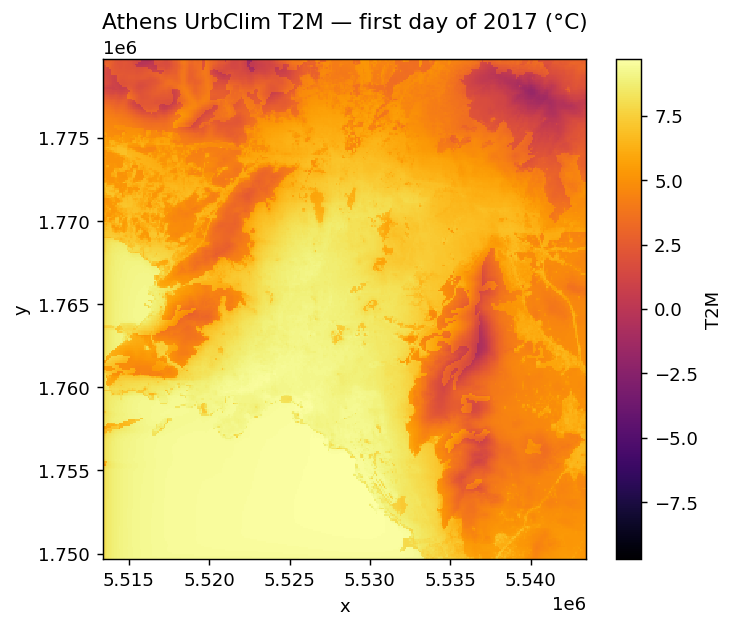

In [23]:
import xarray as xr
import matplotlib.pyplot as plt

f = P("UrbClim/UrbClimT2Mmean/T2M_year_daily_mean_2017.nc")

ds = xr.open_dataset(f)
t2m = ds["T2M"] - 273.15   # Kelvin -> °C

plt.figure(figsize=(6, 5))
t2m.isel(time=0).plot(cmap="inferno")
plt.title(f"{SLUG.title()} UrbClim T2M — first day of 2017 (°C)")
plt.show()

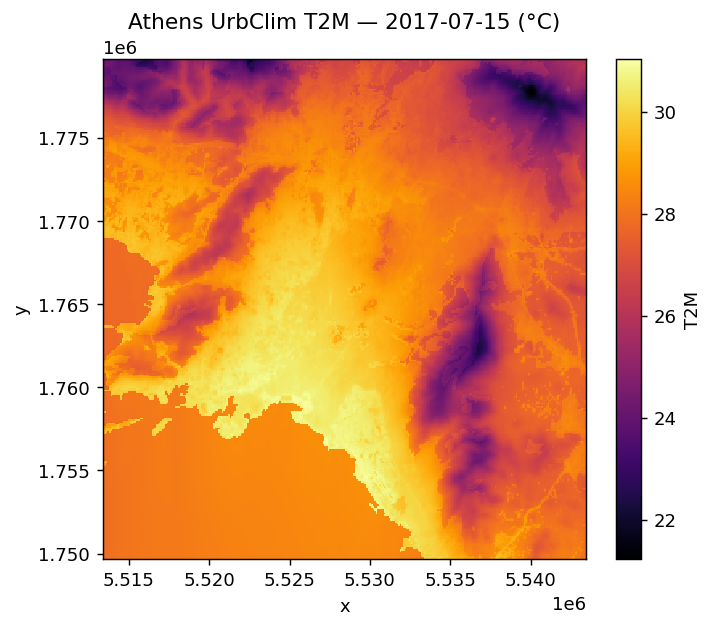

In [24]:
import pandas as pd

date_to_show = "2017-07-15"

plt.figure(figsize=(6, 5))
t2m.sel(time=pd.Timestamp(date_to_show)).plot(cmap="inferno")
plt.title(f"{SLUG.title()} UrbClim T2M — {date_to_show} (°C)")
plt.show()

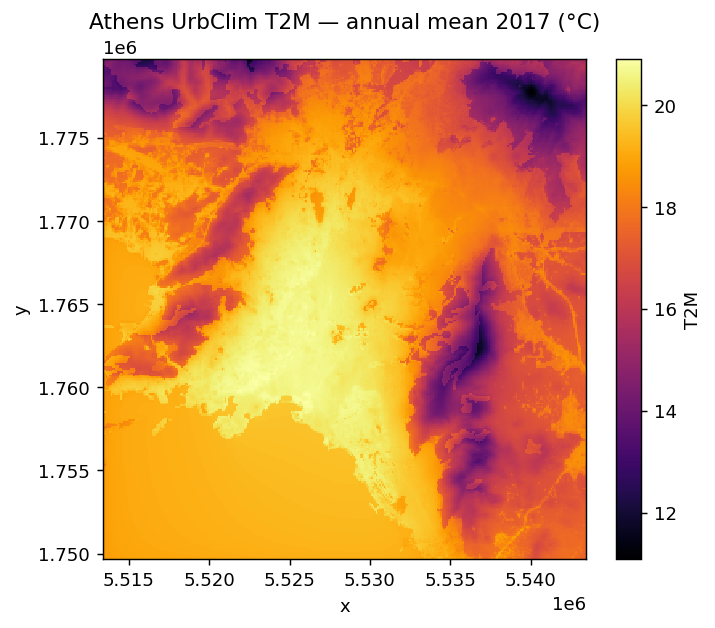

In [25]:
plt.figure(figsize=(6, 5))
t2m.mean("time").plot(cmap="inferno")
plt.title(f"{SLUG.title()} UrbClim T2M — annual mean 2017 (°C)")
plt.show()

In [26]:
# Monthly baseline climatology using T2M (daily mean) from 2008 to 2017
t2m_dir   = P("UrbClim/UrbClimT2Mmean")
t2m_files = sorted(t2m_dir.glob("T2M_year_daily_mean_*.nc"))
assert t2m_files, "No T2M_year_daily_mean_*.nc files found."

ds = xr.open_mfdataset(
    t2m_files,
    combine="by_coords",
    decode_times=True,
    chunks={"time": 90}  
)

# Pick the temperature variable
vname = next((v for v in ("T2M","t2m","tas","temperature") if v in ds.data_vars), list(ds.data_vars)[0])
da = ds[vname]  # daily mean temperature 

# Monthly time series (mean of daily means within each month)
monthly_ts = da.resample(time="MS").mean()  # "MS" = month start

# FUA mask on the UrbClim grid 
from affine import Affine
import rasterio.features as rfeat
from rasterio.crs import CRS

crs_laea = CRS.from_epsg(3035)
fua_laea = fua.to_crs(crs_laea)

x = ds["x"].values
y = ds["y"].values
dx = float(np.diff(x).mean()); dy = float(np.diff(y).mean())

# Affine: pixel centers to shift half a pixel to map to pixel corners
transform = Affine.translation(float(x.min()) - dx/2, float(y.min()) - dy/2) * Affine.scale(dx, dy)
geom_list = [g for g in fua_laea.geometry if g is not None]

mask = rfeat.geometry_mask(
    geom_list,
    out_shape=(len(y), len(x)),
    transform=transform,
    invert=True
)
fua_mask = xr.DataArray(mask, coords={"y": ds["y"], "x": ds["x"]}, dims=("y","x"))

# 2008–2017 monthly climatology: average those monthly means across all years, per month
clim_monthly = monthly_ts.groupby("time.month").mean("time")  # 12 maps (Kelvin)

# City-mean seasonal cycle (full domain vs FUA only)
city_monthly_mean      = clim_monthly.mean(dim=("y","x"))
city_monthly_mean_FUA  = (clim_monthly.where(fua_mask)).mean(dim=("y","x"))

clim_monthly, city_monthly_mean, city_monthly_mean_FUA

(<xarray.DataArray 'T2M' (month: 12, y: 301, x: 301)> Size: 9MB
 dask.array<stack, shape=(12, 301, 301), dtype=float64, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
 Coordinates:
   * x        (x) float64 2kB 5.513e+06 5.514e+06 ... 5.543e+06 5.543e+06
   * y        (y) float64 2kB 1.75e+06 1.75e+06 1.75e+06 ... 1.78e+06 1.78e+06
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
 Attributes:
     units:    K,
 <xarray.DataArray 'T2M' (month: 12)> Size: 96B
 dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12,
 <xarray.DataArray 'T2M' (month: 12)> Size: 96B
 dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12)

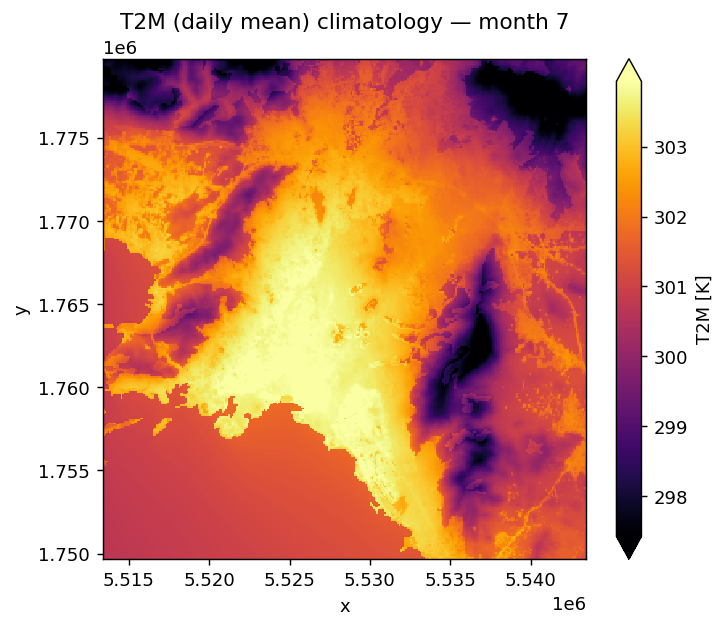

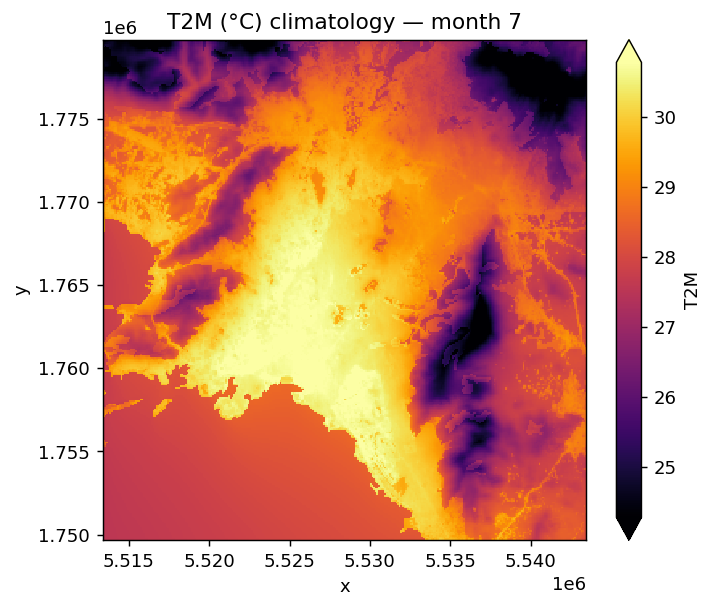

In [27]:
# July map from T2M climatology
month_to_show = 7  # July

# in Kelvin
ax = clim_monthly.sel(month=month_to_show).plot.imshow(
    x="x", y="y", robust=True, cmap="inferno", figsize=(6,5)
)
ax.axes.set_title(f"T2M (daily mean) climatology — month {month_to_show}")
plt.show()

# show in °C 
t2m_c = clim_monthly - 273.15
ax = t2m_c.sel(month=month_to_show).plot.imshow(
    x="x", y="y", robust=True, cmap="inferno", figsize=(6,5)
)
ax.axes.set_title(f"T2M (°C) climatology — month {month_to_show}")
plt.show()

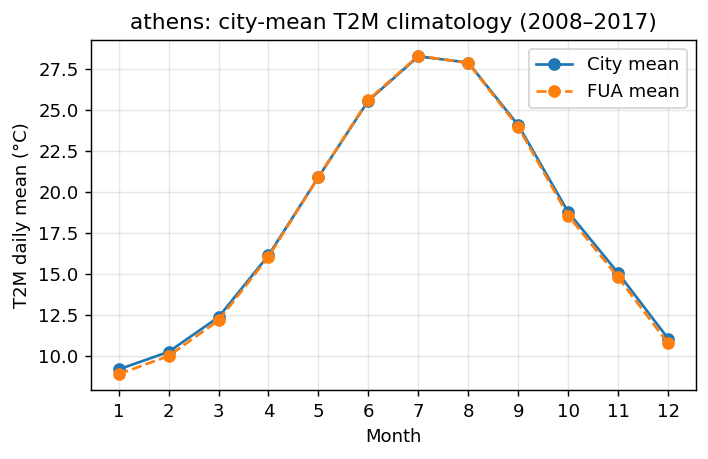

,month,T2M_mean_C_city,T2M_mean_C_FUA
0,1,9.165528,8.872261
1,2,10.235030,9.983776
2,3,12.350996,12.150905
3,4,16.125533,16.033903
4,5,20.892428,20.899983
5,6,25.562025,25.607751
6,7,28.259870,28.299072
7,8,27.876434,27.850805
8,9,24.059446,23.942118
9,10,18.760246,18.540813


In [28]:
# climatology
city_monthly_mean_C = city_monthly_mean - 273.15
city_monthly_mean_FUA_C = city_monthly_mean_FUA - 273.15  

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(range(1,13), city_monthly_mean_C.values, marker="o", label="City mean")
ax.plot(range(1,13), city_monthly_mean_FUA_C.values, marker="o", linestyle="--", label="FUA mean")  
ax.set_xticks(range(1,13)); ax.set_xlabel("Month")
ax.set_ylabel("T2M daily mean (°C)")
ax.set_title(f"{CITY}: city-mean T2M climatology (2008–2017)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

display(pd.DataFrame({
    "month": range(1,13),
    "T2M_mean_C_city": city_monthly_mean_C.values,
    "T2M_mean_C_FUA":  city_monthly_mean_FUA_C.values
}))

### Cooling-Efficiency Coefficient Tables

These CSV tables contain city-, month-, and LCZ-specific coefficients linking greening to temperature changes. They are not used for modelling in NB01, but they are important downstream in the vegetation workflow and should already be present and readable at this stage.


At this stage we only check their availability and schema. Their interpretation and policy use come later, when greening scenarios are translated into temperature changes.


In [29]:
# Inspect the cooling-efficiency coefficient tables that are used later in the vegetation workflow.
print("CoolingEff folder:", p_CoolEff)

coolingeff_csvs = sorted(p_CoolEff.glob("*.csv"))
if not coolingeff_csvs:
    print("No CSV files found in CoolingEff.")
else:
    print(f"Found {len(coolingeff_csvs)} CSV file(s):")
    for i, f in enumerate(coolingeff_csvs, 1):
        print(f"  {i:2d}. {f.name}")

    # Read each file once to confirm its schema and a few example rows.
    coolingeff = {}
    for f in coolingeff_csvs:
        print("\n" + "="*90)
        print(f"FILE: {f.name}")
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print("Could not read CSV:", e)
            continue
        coolingeff[f.stem] = df
        print(f"  shape: {df.shape}")
        print(f"  columns: {list(df.columns)}")
        display(df.head(5))


CoolingEff folder: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/CoolingEff
Found 1 CSV file(s):
   1. coefs_GVI_lst.csv

FILE: coefs_GVI_lst.csv
  shape: (3981, 7)
  columns: ['city', 'lcz', 'month', 'month_name', 'coef', 'se', 't_stat']


,city,lcz,month,month_name,coef,se,t_stat
0,Accra,3,1,Jan,-0.043834,0.013651,-3.210956
1,Accra,3,2,Feb,-0.055282,0.014314,-3.862189
2,Accra,3,3,Mar,-0.047536,0.014257,-3.334203
3,Accra,3,4,Apr,-0.039965,0.013909,-2.873380
4,Accra,3,8,Aug,-0.028955,0.011733,-2.467807


### Saving the Masked LCZ Raster

We export the FUA-masked LCZ raster once here so that later notebooks can reuse it directly instead of repeating the same clipping step.


In [30]:
# Persist the FUA-masked LCZ raster for reuse in downstream notebooks.
lcz_out = OUTP("lcz_masked_fua.tif")
with rasterio.open(lcz_out, "w", **lcz_meta) as dst:
    dst.write(lcz_fua, 1)
print("Saved:", lcz_out)


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/lcz_masked_fua.tif
